# Predicting Employee Attrition 

In [65]:
#Importing necessary libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importing the required ML packages 
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
     roc_curve, auc, roc_auc_score, confusion_matrix, RocCurveDisplay
)
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from dmba import classificationSummary

In [2]:
# Load dataset
df = pd.read_csv("HR-Employee-Attrition.csv")

# Basic check
print(df.shape) #Dimension of the dataset
df.head() 

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 1. Data Cleaning 

In [3]:
# Removing duplicates to have all unique records
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicates: 0


In [4]:
# Checking for any missing values
df.isna().sum().sort_values(ascending=False)

Age                         0
StandardHours               0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
MonthlyIncome               0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
MonthlyRate                 0
MaritalStatus               0
Attrition                   0
EmployeeCount               0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeNumber              0
JobSatisfaction             0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole   

In [5]:
#To find any non-significant variables for our model
df.nunique()
#We decide to drop all the variables with unique value = 1, since they do not contribute to our analysis.

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

In [6]:
# Dropping irrelevant columns not required for our analysis as they may not affect attrition
cols_to_drop = ["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"]
for col in cols_to_drop:
    if col in df.columns:
        df = df.drop(columns=col)

In [7]:
#We now have 31 columns instead of 35.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [8]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


### Initial Visualizations

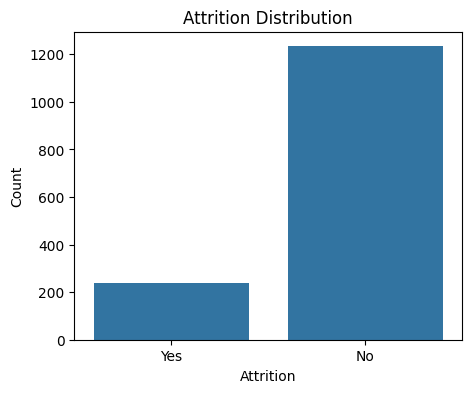

Attrition rate (proportion):
Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


In [9]:
# Attrition distribution to check class imbalance
plt.figure(figsize=(5, 4))
sns.countplot(x="Attrition", data=df)
plt.title("Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Count")
plt.show()

# Also show proportions
attrition_rate = df["Attrition"].value_counts(normalize=True)
print("Attrition rate (proportion):")
print(attrition_rate)

### Interpretation
The bar chart shows a clear class imbalance, with a significantly larger number of employees staying compared to those who left. This imbalance is common in HR datasets and is important to recognize early, as it affects how model performance should be interpreted. The attrition rate observed is 16.12% while non-attrition is 83.88%.  

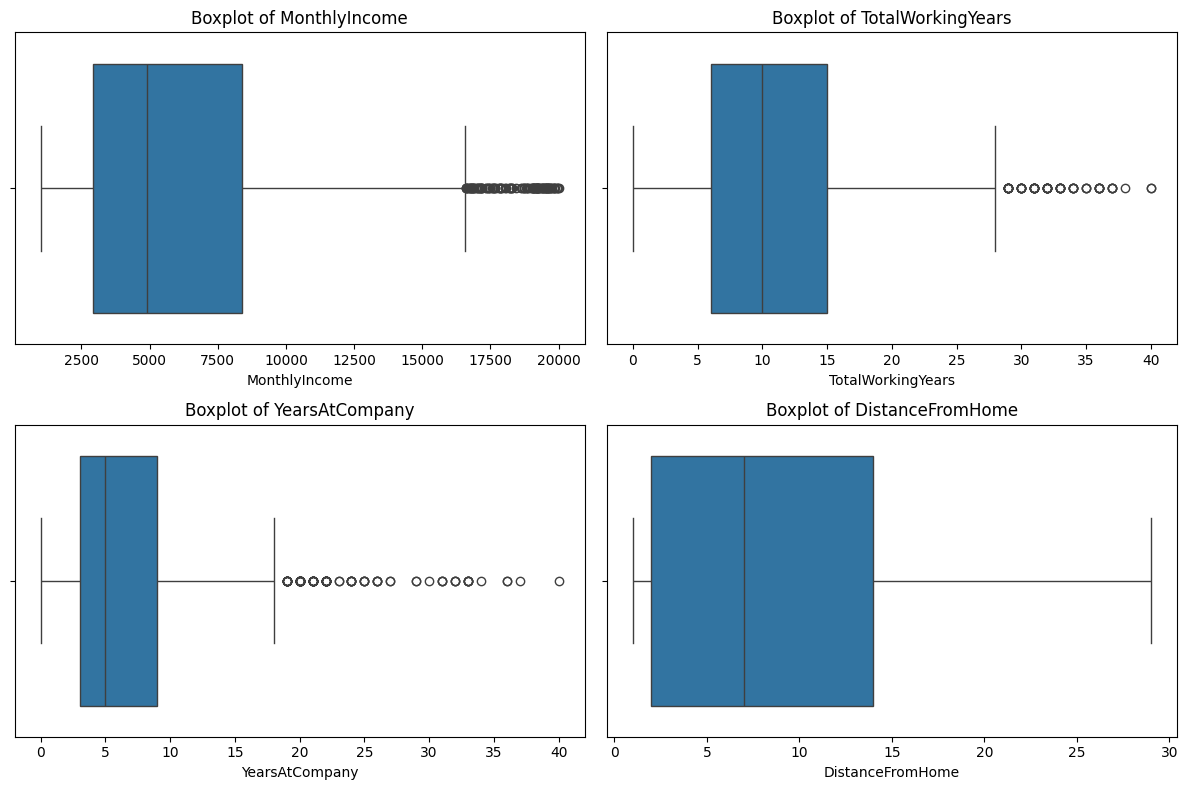

In [10]:
# Boxplot to check for any outliers and distribution of the continuous variable
numeric_cols_to_check = [
    "MonthlyIncome", "TotalWorkingYears",
    "YearsAtCompany", "DistanceFromHome"
]

plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_cols_to_check, 1):
    if col in df.columns:
        plt.subplot(2, 2, i)
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

### Interpretation
The purpose of creating these boxplots is to highlight the presence of outliers, differences in spread, and potential irregularities in the data.
- MonthlyIncome- The boxplot for Monthly Income highlights the spread of salaries and identifies several high income outliers. The wide range indicates variation in pay across job roles and levels. This visualization helps confirm that income is a variable with meaningful variability, making it relevant for deeper attrition analysis.
- TotalWorkingYears- The boxplot shows a broad distribution, with employees ranging from early career to highly experienced. A few outliers represent individuals who have worked in the company for long. 
- YearsAtCompany- The boxplot shows that most employees have relatively short tenure, with a few long tenured outliers. This is in contrast with the histogram of YearsAtCompany and confirms that tenure varies widely, making it a potentially important factor in attrition.
- DistanceFromHome- The boxplot shows that most employees live relatively close to the workplace. The long tail represents employees who have to commute much farther. This variation suggests that commute distance may influence employee satisfaction and is worth examining in relation to attrition.


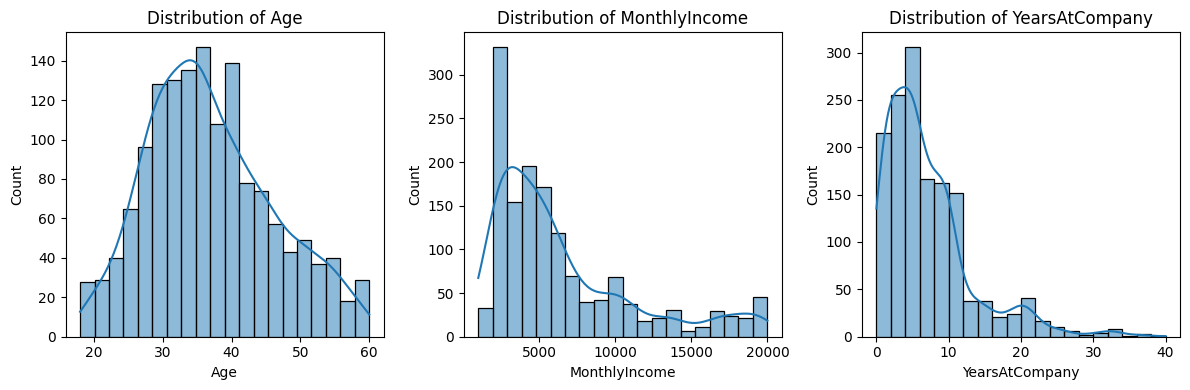

In [11]:
# To check for any skewness in the distribution 
hist_cols = ["Age", "MonthlyIncome", "YearsAtCompany"]

plt.figure(figsize=(12, 4))
for i, col in enumerate(hist_cols, 1):
    if col in df.columns:
        plt.subplot(1, 3, i)
        sns.histplot(df[col], bins=20, kde=True)
        plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

### Interpretation
The focus of this analysis is to observe central tendencies, skewness, and the general shape of the data. These plots helped identify whether the workforce was young or older, whether income was evenly distributed or skewed, and whether most employees had short or long tenure. 
- Age Distribution- The distribution is slightly right skewed, with most employees falling between their late 20s and early 40s. Very young and very old employees make up a smaller portion of the workforce. This tells us the general age structure of the company and confirms that the dataset contains a mature employee population.
- MonthlyIncome Distribution- The distribution is heavily right-skewed, pointing out that most employees earn on the lower end of the salary range, and only a small number earn very high incomes. This skewness is typical in corporate salary structures and indicates that income is not evenly distributed.
- YearsAtCompany Distribution- The histogram shows a large proportion of employees having relatively short tenure, with the distribution decreasing as years increase. This suggests that the workforce contains many newer employees and fewer long tenured staff.


## 2. Data Transformation

In [12]:
# Convert target variable (Attrition) to binary
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

In [13]:
#Count of yes (1) and no (0) for attrition
df["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [14]:
# Identify numeric and categorical columns to later one-hot encode the variables
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_features = [col for col in numeric_features if col != "Attrition"]

categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

numeric_features, categorical_features

(['Age',
  'DailyRate',
  'DistanceFromHome',
  'Education',
  'EnvironmentSatisfaction',
  'HourlyRate',
  'JobInvolvement',
  'JobLevel',
  'JobSatisfaction',
  'MonthlyIncome',
  'MonthlyRate',
  'NumCompaniesWorked',
  'PercentSalaryHike',
  'PerformanceRating',
  'RelationshipSatisfaction',
  'StockOptionLevel',
  'TotalWorkingYears',
  'TrainingTimesLastYear',
  'WorkLifeBalance',
  'YearsAtCompany',
  'YearsInCurrentRole',
  'YearsSinceLastPromotion',
  'YearsWithCurrManager'],
 ['BusinessTravel',
  'Department',
  'EducationField',
  'Gender',
  'JobRole',
  'MaritalStatus',
  'OverTime'])

In [15]:
# One-hot encoding to convert all the categorical variables into binary columns
df_encoded = pd.get_dummies(df, drop_first=True)

In [16]:
# Separate features and target
X = df_encoded.drop(columns=["Attrition"])
y = df_encoded["Attrition"]

#Split data into training and test set in the ratio of 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)

In [17]:
#Scaling only the numeric variables to be used in our models. 
#Avoid categorical variables since they are already encoded to binary

scaler = StandardScaler()

X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

## 3. Exploratory Data Analysis (EDA)

#### Univariate Analysis

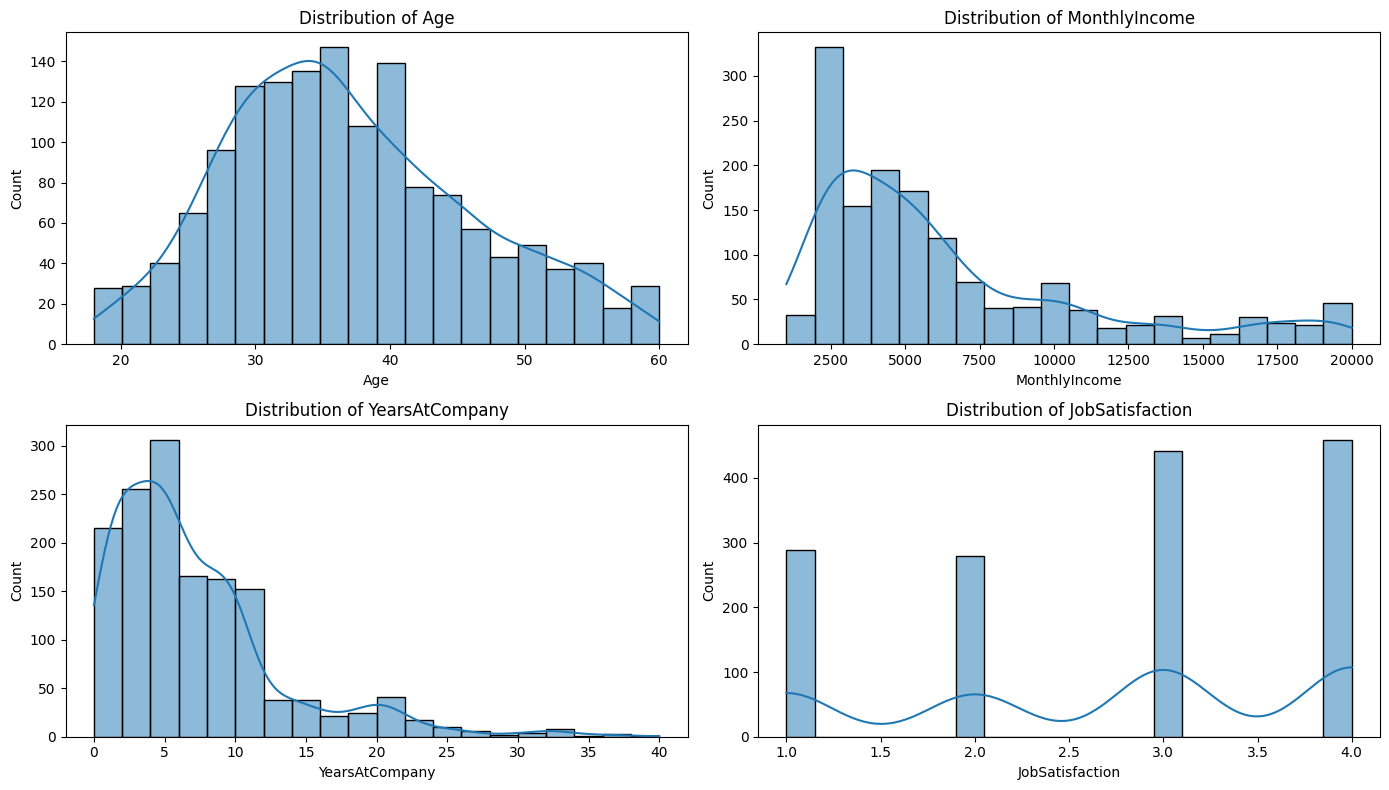

In [18]:
univariate_cols = ["Age", "MonthlyIncome", "YearsAtCompany", "JobSatisfaction"]

plt.figure(figsize=(14, 8))
for i, col in enumerate(univariate_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

### Analysis
#### These distribution gives us an idea of what might drive attrition.
1. Age: The age distribution of the workforce is clustered between the range of 30-40 years. The middle-aged employees usually have lower intention to leave the company due to personal responsibilities which is why they would prefer job security. Younger employees on the other hand might have a higher change of attrition. They have higher risk appetite and longer time horizon before them which is why they would want to explore other opportunities and seek faster career growth.
2. MonthlyIncome: This distribution is right-skewed, with many employees earning on the lower end. Low income employees have a higher chance of attrition while the high-income earners tend to stay in the company.
3. YearsAtCompany: The distribution is also right-skewed, indicating that majority of the employees have low tenure between 0-5 years. Employees with shorter tenure are generally more likely to leave the company.
4. JobSatisfaction: From the distribution, the majority of the employees are satisfied with their job while less than half are not. The employees with low job satisfaction shows higher attrition rate and should be paid more attention to retain talent.

Across all four variables, a consistent pattern emerges where younger and Lower‑income employees with Short‑tenured, and Employees with low job satisfaction are more likely to leave.

#### Bivariate Analysis

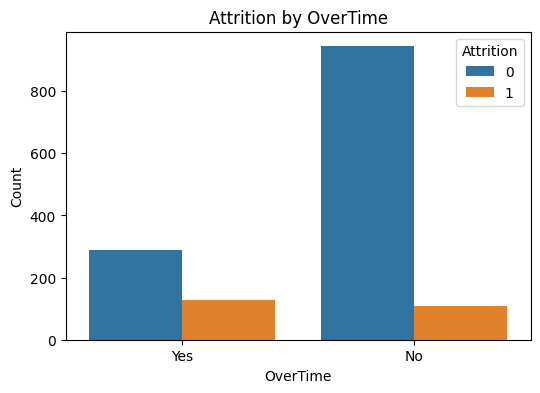

In [19]:
#Attrition v/s Overtime
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="OverTime", hue="Attrition")
plt.title("Attrition by OverTime")
plt.ylabel("Count")
plt.show()

### Analysis
The bar chart shows that employees who do not work overtime relatively have a higher count of non‑attrition, indicating that the majority of them remain with the company. In contrast, employees who do work overtime show a noticeable proportion of attrition relative to their group size. Although the number of attrition cases is smaller overall, the difference in proportions is clear: employees who work overtime are more likely to leave the organization.

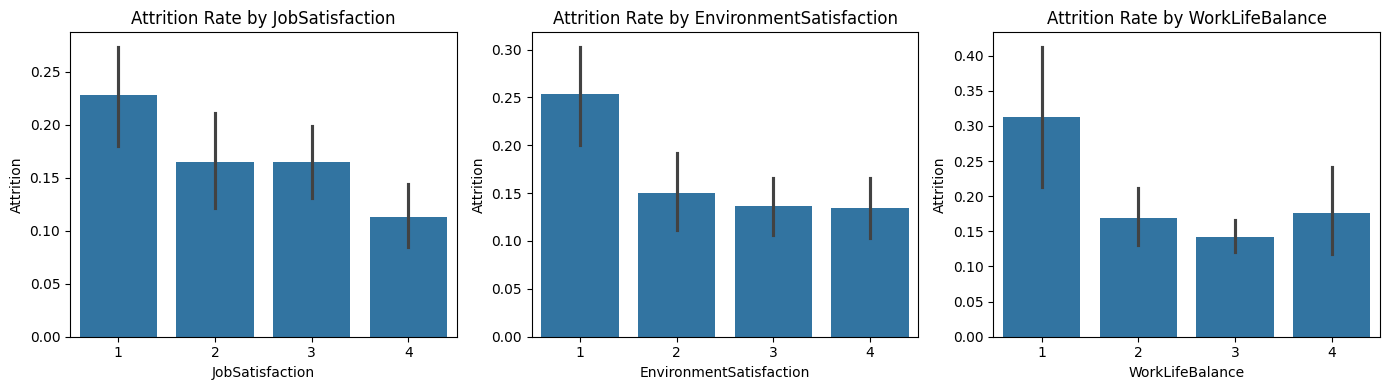

In [20]:
#Attrition v/s Satisfaction scores and Work-life balance
satisfaction_cols = ["JobSatisfaction", "EnvironmentSatisfaction", "WorkLifeBalance"]

plt.figure(figsize=(14, 4))
for i, col in enumerate(satisfaction_cols, 1):
    plt.subplot(1, 3, i)
    sns.barplot(
        data=df,
        x=col,
        y="Attrition",
        estimator=lambda x: sum(x) / len(x),  # proportion of attrition
    )
    plt.title(f"Attrition Rate by {col}")
plt.tight_layout()
plt.show()

### Analysis
1. Attrition by JobSatisfaction: Employees with the lowest satisfaction level have the highest attrition rate, while those with the highest satisfaction have the lowest turnover. The decline in attrition as satisfaction increases suggests that employees who feels valued and engaged in their roles are significantly less likely to leave.
2. Attrition by EnvironmentSatisfaction: Employees who rate their work environment poorly have the highest attrition rate. As satisfaction improves from levels 2 to 4, attrition decreases noticeably. This indicates that the physical and psychological work environment such as workplace culture, safety, and support plays an important role in employee retention. Employees who perceive their environment as unsupportive or stressful are more likely to seek opportunities elsewhere.
3. Attrition by WorkLifeBalance: Employees with the lowest work‑life balance rating have the highest attrition rate, exceeding 0.3 or 30%. Attrition drops sharply for employees with moderate to high work‑life balance ratings, with the lowest observed at level 3. This suggests that employees who struggle to balance personal and professional life are at higher risk of leaving. Poor work‑life balance often results from excessive workload, long hours, or unpredictable schedules, resulting in employee's burnout from work.

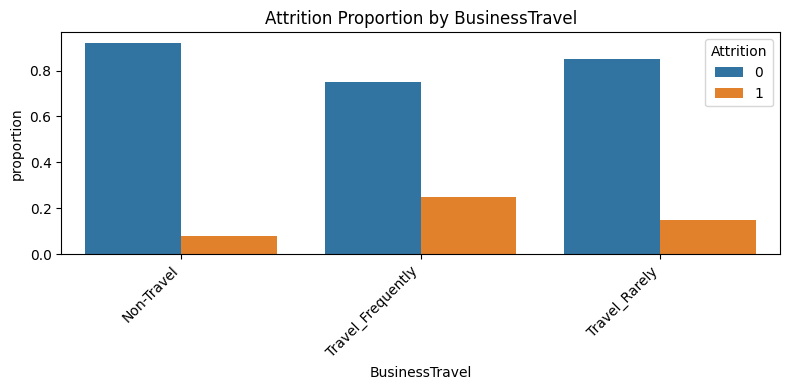

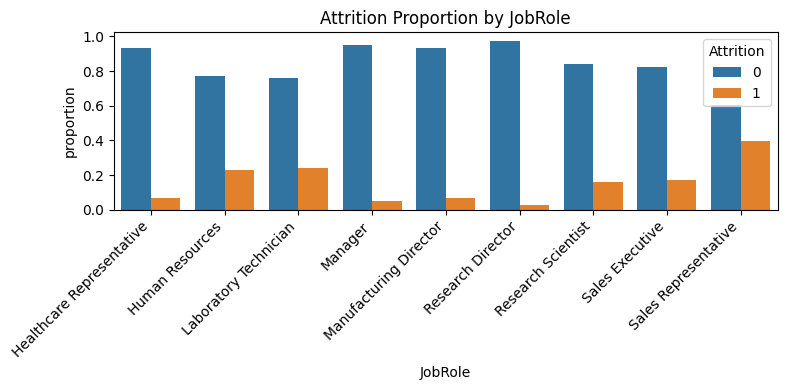

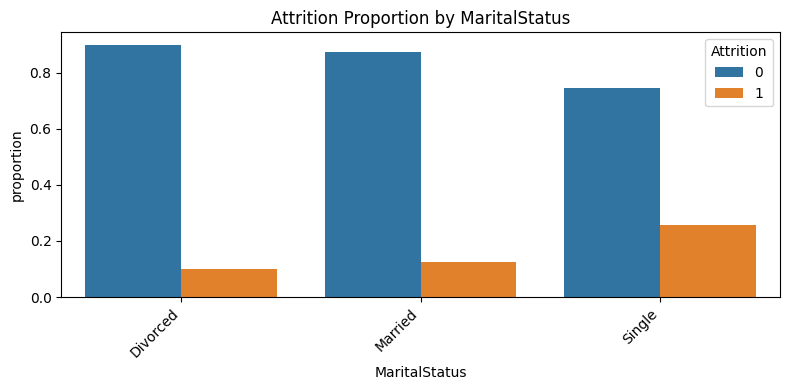

In [21]:
#Attrition v/s Job demand and Marital Status
cat_cols = ["BusinessTravel", "JobRole", "MaritalStatus"]

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    prop = (
        df.groupby(col)["Attrition"]
        .value_counts(normalize=True)
        .rename("proportion")
        .reset_index()
    )
    sns.barplot(data=prop, x=col, y="proportion", hue="Attrition")
    plt.title(f"Attrition Proportion by {col}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

### Analysis
1. Attrition by BusinessTravel: The bar chart clearly shows employees who do not travel have the lowest attrition proportion, suggesting that a stable, predictable work routine supports retention. Attrition increases among those who travel rarely, and is highest among employees who travel frequently. Frequent travel can contribute to fatigue, work–life imbalance, and stress, which may explain the higher turnover.
2. Attrition by JobRole: The chart shows that most roles have low attrition rate however, Sales Representatives, Lab Technician and Human Resources employees shows noticeably higher attrition rates. These roles often involve high interpersonal demands, performance pressure, or administrative workload, which may contribute to increased turnover. 
3. Attrition by MaritalStatus: The chart reveals that single employees have a significantly higher proportion of attrition compared to married or divorced employees. Married and divorced individuals show much higher proportions of non‑attrition, indicating greater stability. This pattern may reflect lifestyle differences—single employees may have fewer family‑based commitments, greater mobility, or a higher likelihood of pursuing new opportunities.

We can conclude that employees who have to travel more frequently with marital status as Single have a higher chance of leaving the company. Roles that have higher expectation from the employees with more pressure and stress also leads to attrition. 

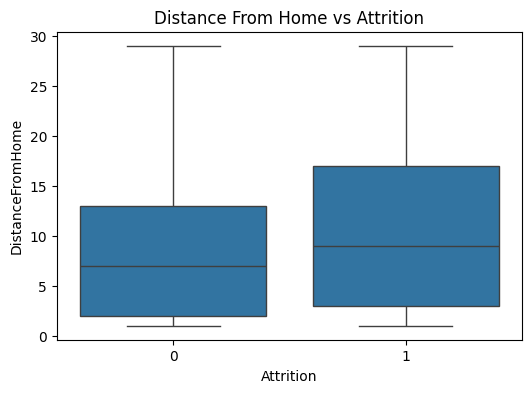

In [22]:
#Attrition v/s Distance from Home
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Attrition", y="DistanceFromHome")
plt.title("Distance From Home vs Attrition")
plt.show()

### Analysis
The boxplot reveals a similar pattern yet subtle. Employees who left the company tend to live slightly farther from the workplace than those who stayed. The median distance for the attrition group is higher, and the interquartile range is wider, indicating greater variability in commute length among employees who left. Although both groups share similar minimum and maximum values, the upward shift in the central tendency suggests that longer commute distances may contribute to dissatisfaction or reduced work–life balance. 

#### Multivariate Analysis

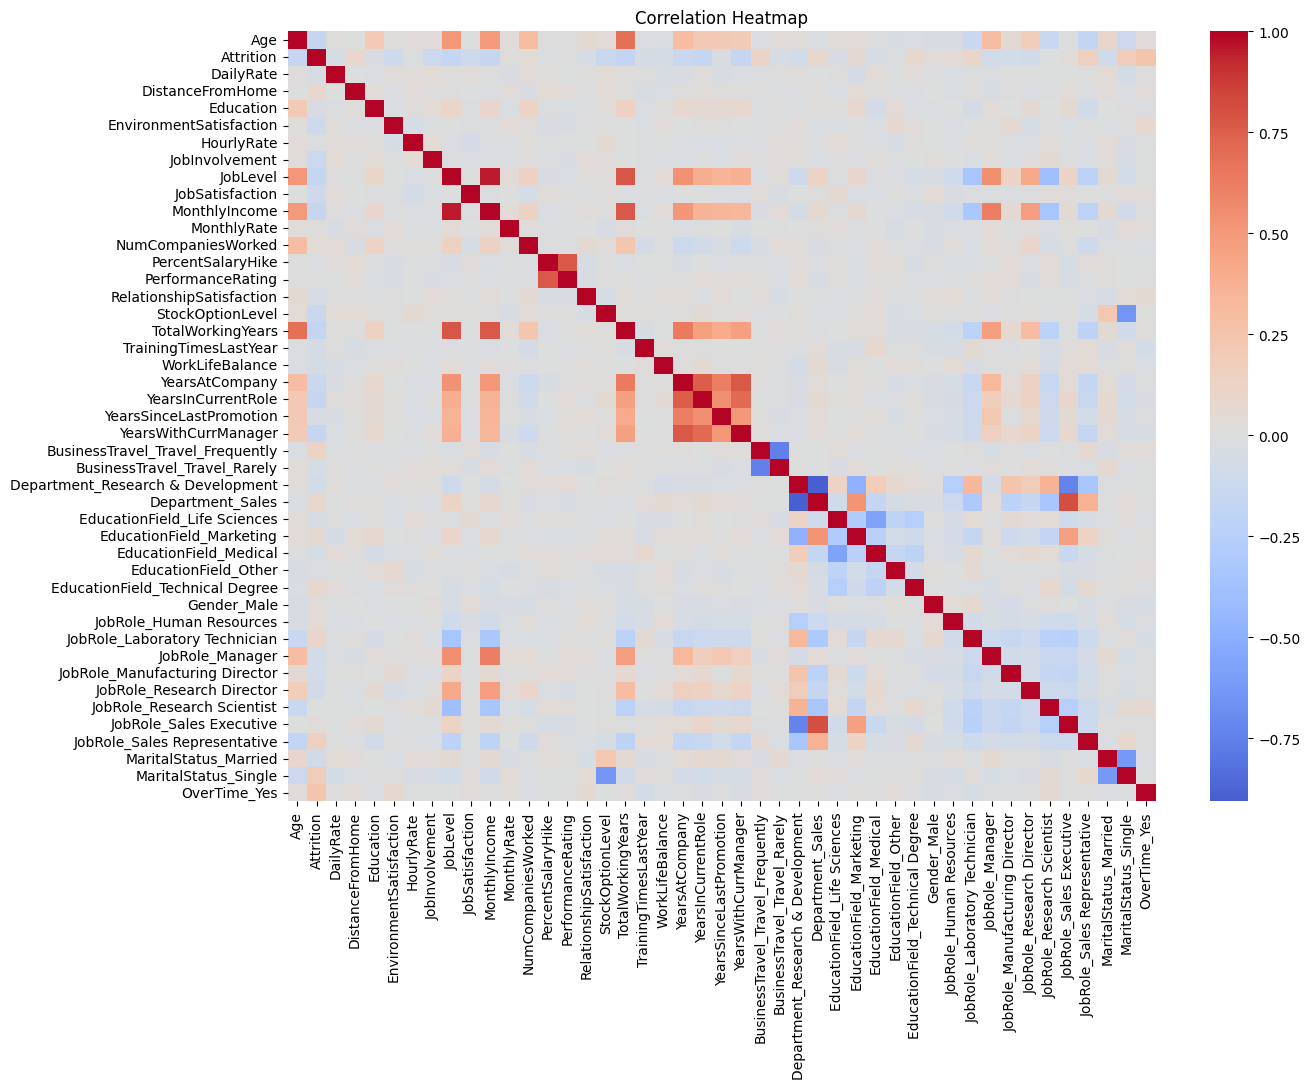

In [23]:
#Correlation Heatmaps
plt.figure(figsize=(14, 10))
corr = df_encoded.corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

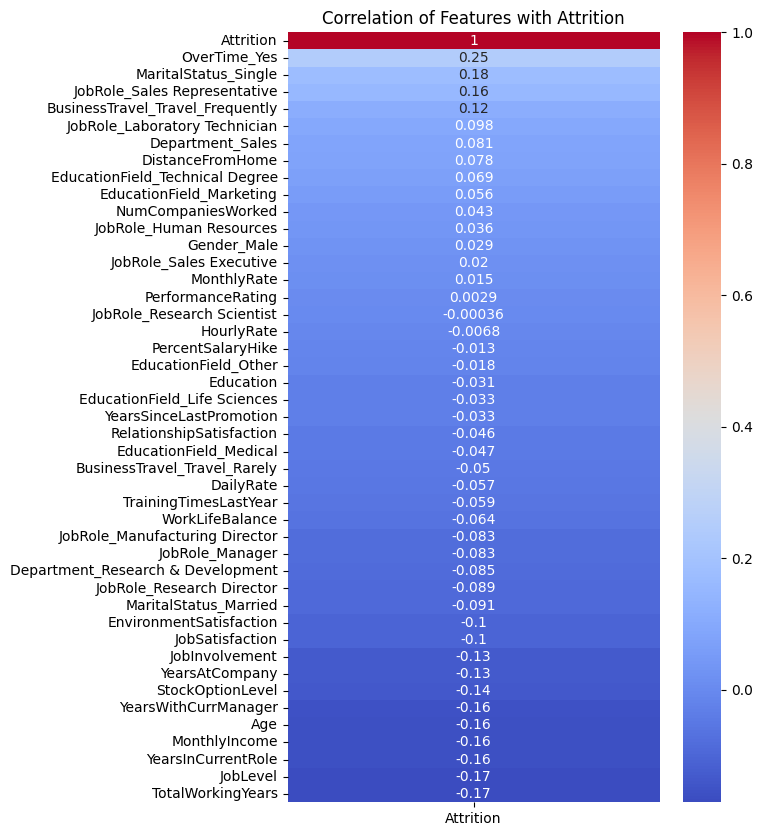

In [24]:
#Correlation coefficients of all the variables against attrition
plt.figure(figsize=(6, 10))
sns.heatmap(corr[["Attrition"]].sort_values(by="Attrition", ascending=False), 
            annot=True, cmap="coolwarm")
plt.title("Correlation of Features with Attrition")
plt.show()

### Analysis
##### Correlation Heatmap and Correlation Coefficient Heatmap
The two heatmaps together provide a comprehensive multivariate view of how different employee attributes relate to attrition and to one another. The single‑target heatmap highlights the features that is directly associated with attrition, showing that OverTime, MaritalStatus_Single, certain JobRoles, and frequent business travel have comparatively positive correlations with employees leaving the company. On the other hand, variables related to tenure, experience, job level, age, and monthly income show moderate negative correlations, indicating that more senior, experienced, and higher‑paid employees are less likely to leave.
Overall, the heatmaps reveals that attrition is driven by a combination of workload (OverTime), compensation (MonthlyIncome, JobLevel), career stage (Age, TotalWorkingYears), and job context (JobRole, BusinessTravel). While no single factor solely predicts turnover, the combined patterns provide strong guidance for feature selection and model interpretation.

## Overall EDA Analysis
Exploratory Data Analysis across univariate, Bivariate and Multivariate Analysis collectively helped us figure out the factors that drives attrition. The univariate analysis highlighted variables that had meaningful variation such as the skewed distributions of MonthlyIncome, YearsAtCompany, and DistanceFromHome. These were necessary to understand the distribution of the variable along with any unusual patterns that may affect attrition. The bivariate analysis showed clear differences between employees who stayed and those who left. Employees with lower monthly income, shorter tenure, fewer total working years, longer commute distances, and lower satisfaction levels were consistently associated with higher attrition. Categorical comparisons further proved that employees who worked overtime, travelled frequently, held certain job roles, or were single showed higher attrition rates. The multivariate heatmaps confirmed these relationships by showing positive correlations between attrition and factors such as overtime, single marital status, and frequent travel, while negative correlations emerged for income, job level, age, and tenure‑related variables. Together, these analyses demonstrate that attrition is not influenced by a single factor but a combination of demographic, job‑related, behavioral, and satisfaction‑based factors.


## 4. Classification Model Experiment and Evaluation

### KNN Classification Model

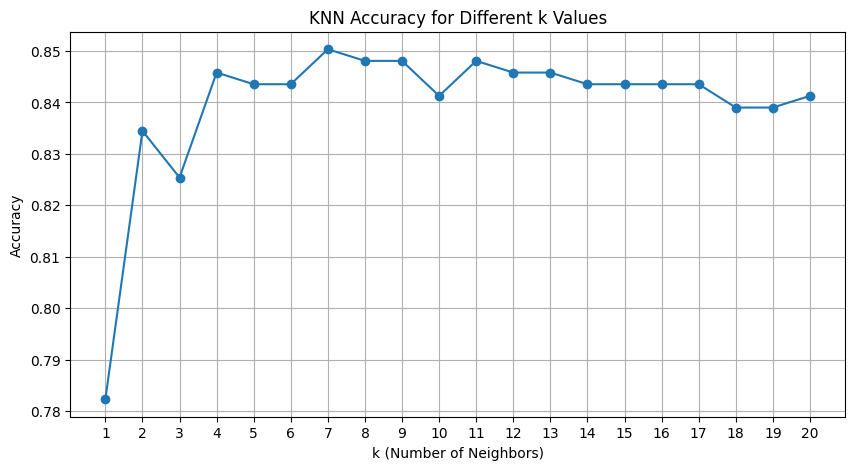

In [50]:
#Creating KNN Classification Model

# Running KNN with a range of k values 1-20 to find the most opitmal k
k_values = range(1, 21)
accuracy_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test, y_pred))

# Plot accuracy vs k
plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracy_scores, marker='o')
plt.title("KNN Accuracy for Different k Values")
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.grid(True)
plt.show()

#### Conclusion-  The value k=7 gives the highest accuracy therefore, we will create the model with this value.

In [51]:
# KNN Classification with optimal k = 7
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
y_proba_knn = knn.predict_proba(X_test)[:, 1]

# Model Evaluation by Accuracy, Precision, Recall, F1 score and AUC
print("=== KNN (k = 7) ===")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

=== KNN (k = 7) ===
Accuracy : 0.8503401360544217
Precision: 0.6923076923076923
Recall   : 0.1267605633802817
F1 Score : 0.21428571428571427


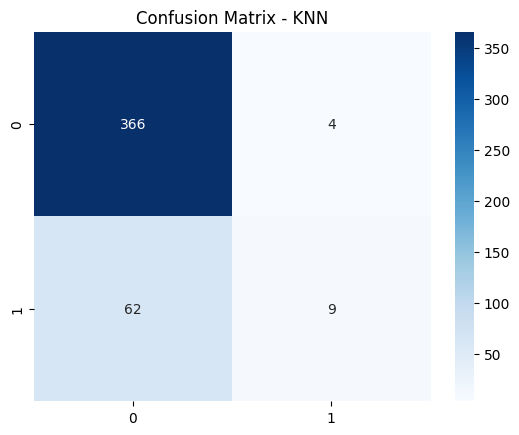

In [52]:
#Model Evaluation by Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - KNN")
plt.show()

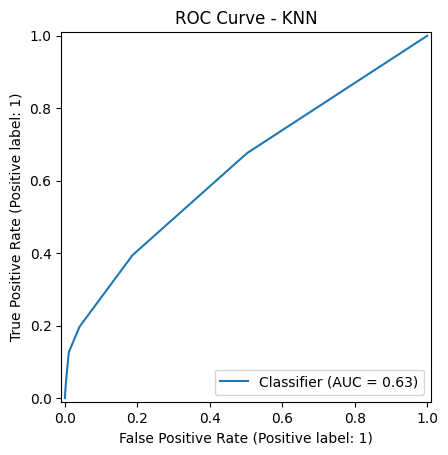

In [53]:
# Model Evaluation by ROC Curve
RocCurveDisplay.from_predictions(y_test, y_proba_knn)
plt.title("ROC Curve - KNN")
plt.show()

### Naive Bayes Classification Model

In [54]:
#Creating NB Classification Model
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)
y_proba_nb = nb.predict_proba(X_test)[:, 1]

#Model Evaluation by Accuracy, Precision, Recall, F1 score and AUC
print("=== Naive Bayes ===")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

=== Naive Bayes ===
Accuracy : 0.6349206349206349
Precision: 0.265625
Recall   : 0.7183098591549296
F1 Score : 0.38783269961977185


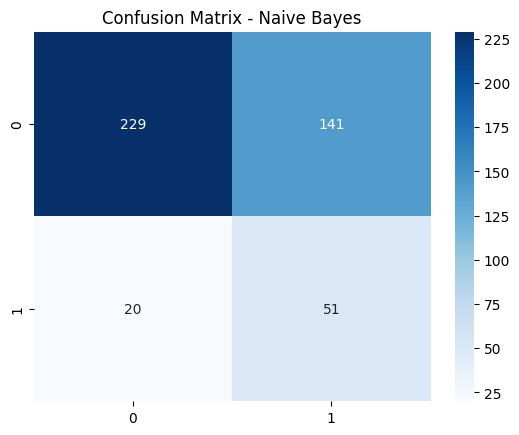

In [55]:
#Model Evaluation by Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

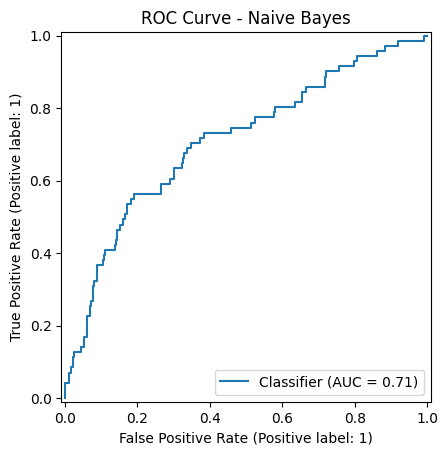

In [56]:
#Model Evaluation by ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba_nb)
plt.title("ROC Curve - Naive Bayes")
plt.show()

### Logistic Regression

In [57]:
#Creating Logistic Regression Model 
log_reg = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    solver="lbfgs")

log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

#Model Evaluation by Accuracy, Precision, Recall, F1 score and AUC
print("=== Logistic Regression ===")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

=== Logistic Regression ===
Accuracy : 0.7596371882086168
Precision: 0.37037037037037035
Recall   : 0.704225352112676
F1 Score : 0.4854368932038835


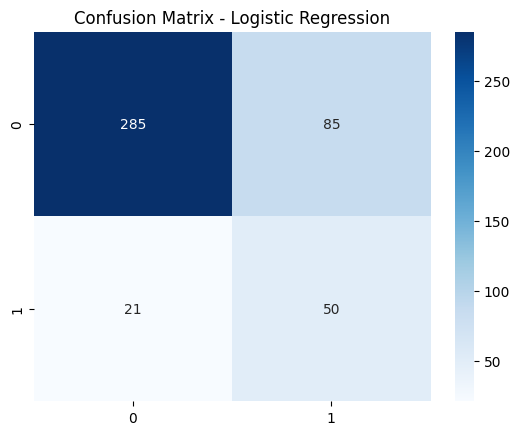

In [58]:
#Model Evaluation by Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

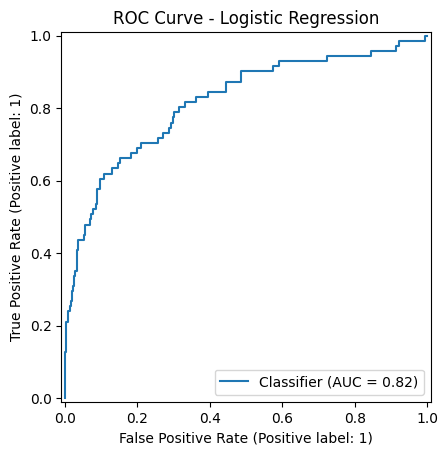

In [59]:
#Model Evaluation by ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba_lr)
plt.title("ROC Curve - Logistic Regression")
plt.show()

### Neural Network Model

In [60]:
nn_model = MLPClassifier(
    hidden_layer_sizes=(3,),
    activation='logistic',
    solver='lbfgs',
    random_state=42)

nn_model.fit(X_train, y_train)

y_pred = nn_model.predict(X_test)
y_proba_nn = nn_model.predict_proba(X_test)[:, 1]

#Model Evaluation by Accuracy, Precision, Recall, F1 score and AUC
print("=== Neural Network ===")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

=== Neural Network ===
Accuracy : 0.854875283446712
Precision: 0.5522388059701493
Recall   : 0.5211267605633803
F1 Score : 0.5362318840579711


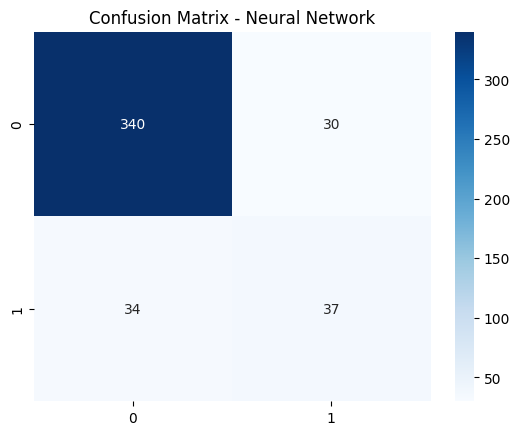

In [61]:
#Model Evaluation by Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Neural Network")
plt.show()

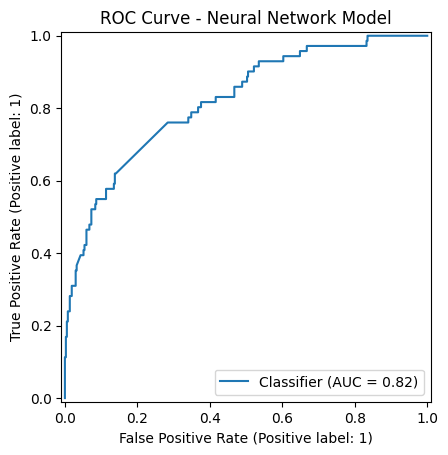

In [62]:
#Model Evaluation by ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba_nn)
plt.title("ROC Curve - Neural Network Model")
plt.show()

### Model Comparison by Evaluation Metrics

In [63]:
#Created a dataframe to compare all the models side by side in a tabular format
results_df = pd.DataFrame({
    "Model": ["KNN", "Naive Bayes", "Logistic Regression", "Neural Network"],
    "Accuracy": [0.850,0.635,0.760, 0.855],
    "Precision": [0.692,0.266,0.370, 0.552],
    "Recall": [0.127,0.718,0.704, 0.521],
    "F1 Score": [0.214,0.388,0.485, 0.536]})
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,0.850,0.692,0.127,0.214
1,Naive Bayes,0.635,0.266,0.718,0.388
2,Logistic Regression,0.760,0.370,0.704,0.485
3,Neural Network,0.855,0.552,0.521,0.536


### Model Comparison by ROC Curve

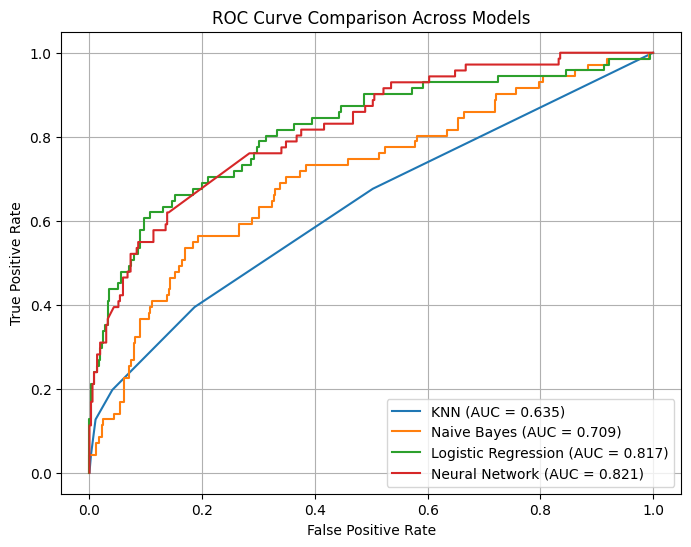

In [67]:
plt.figure(figsize=(8,6))

# KNN
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
auc_knn = auc(fpr_knn, tpr_knn)
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {auc_knn:.3f})")

# Naive Bayes
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_proba_nb)
auc_nb = auc(fpr_nb, tpr_nb)
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC = {auc_nb:.3f})")

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")

# Neural Network
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_proba_nn)
auc_nn = auc(fpr_nn, tpr_nn)
plt.plot(fpr_nn, tpr_nn, label=f"Neural Network (AUC = {auc_nn:.3f})")


# Plot formatting for all the ROC curve across models
plt.title("ROC Curve Comparison Across Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()